In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# pip install torchvision
# 

In [3]:
import os,sys
#sys.path.append('/work/qdiff/mo_utils')
sys.executable


'/home/nadavg/phase2-sdk/sdk_virtualenv/bin/python'

In [4]:
print(os.getcwdb())
os.chdir('/home/nadavg/q-diffusion')
print(os.getcwdb())

b'/home/nadavg/q-diffusion/scripts/hf15'
b'/home/nadavg/q-diffusion'


In [5]:
os.environ['CUDA_VISIBLE_DEVICES'] = '5'

In [6]:
import torch
torch.cuda.is_available()

True

In [7]:
from mo_utils.utils.stand_alone_utils.har_utils import get_har_files,get_params_from_har
from mo_utils.utils.stand_alone_utils.pytorch2accelras import (
    get_nested_attr,
    get_weight_and_bias_from_layer_name,
    acc_ker_to_pytorch_weight,
    UpdateUnet,
    )
from mo_utils.utils.stand_alone_utils.quant_utils import calc_snr,calc_stats


In [8]:
from src.utils.torch_utils import add_full_name_to_module
from scripts.hf15.init_pipe import init_pipe

/home/nadavg/phase2-sdk/sdk_virtualenv/lib/python3.10/site-packages/flax/struct.py:136: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/nadavg/phase2-sdk/sdk_virtualenv/lib/python3.10/site-packages/flax/struct.py:136: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
2025-05-09 00:03:45.628446: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/nadavg/phase2-sdk/sdk_virtualenv/lib/python3.10/site-packages/flax/struct.py:136: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, k

In [9]:
import netron
from pathlib import Path
from collections import namedtuple
from pathlib import Path

In [10]:
import torch
import torch.nn as nn
from diffusers import StableDiffusionPipeline
from scripts.hf15.txt2img import get_train_samples
from qdiff.quant_model import QuantModel,init_qnn_from_fp_model,init_qnn_from_qdiff_opt

/home/nadavg/phase2-sdk/sdk_virtualenv/lib/python3.10/site-packages/transformers/models/clip/feature_extraction_clip.py:28: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(


In [11]:
#qdiff_opt_path = Path('/workspace/sd/qdiff_hf15/output_quantization/2025-04-29-11-17-50/') # sm_ab = 8
#qdiff_opt_path = Path('/workspace/sd/qdiff_hf15/output_quantization/2025-04-22-17-24-29/') # sm_ab = 16
#qdiff_opt_path = Path('/workspace/sd/qdiff_hf15/output_quantization/2025-05-06-00-33-15') ## sm_ab = 16 0-1

In [12]:
# verh 
#qdiff_opt_path = Path('/workspace/sd/qdiff_hf15/output_quantization/2025-05-07-01-21-33/') # sm_ab = 8 ,16bit-rtn true 
#qdiff_opt_path = Path('/workspace/sd/qdiff_hf15/output_quantization/2025-05-07-01-20-26/') # sm_ab = 8 ,16bit-rtn false 
#qdiff_opt_path = Path('/workspace/sd/qdiff_hf15/output_quantization/2025-05-07-01-18-38/') # sm_ab = 16 ,16bit-rtn false 
#qdiff_opt_path = Path('/workspace/sd/qdiff_hf15/output_quantization/2025-05-07-01-17-40/') # sm_ab = 16 ,16bit-rtn true

In [ ]:
# veri 
#qdiff_opt_path = Path('/workspace/sd/qdiff_hf15/output_quantization/2025-05-08-16-58-12/') # sm_ab = 16 ver1
#qdiff_opt_path = Path('/workspace/sd/qdiff_hf15/output_quantization/2025-05-08-16-57-54/') # sm_ab = 16 ver0
qdiff_opt_path = Path('/workspace/sd/qdiff_hf15/output_quantization/2025-05-08-16-57-29/') # sm_ab = 8 

In [28]:
! ls -l {qdiff_opt_path}

total 6724965
-rw-r--r-- 1 nadavg ht 6880123470 May  8 21:24 ckpt.pth
-rw-r--r-- 1 nadavg ht     407509 May  8 21:24 grid-0000.png
-rw-r--r-- 1 nadavg ht    6728658 May  8 21:26 grid-val_images.png
-rw-r--r-- 1 nadavg ht       2256 May  8 21:24 opt.pth
-rw-r--r-- 1 nadavg ht     172478 May  8 21:26 run.log


In [29]:
qnn,pipe,uu = init_qnn_from_qdiff_opt(qdiff_opt_path)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


SNR of acceleras fp model : 122.29099508123328 [db]


In [30]:
qdiff_matmul1_limvals,qdiff_matmul2_limvals,qdiff_convs_limvals,qdiff_lnorm_limvals = uu.save_limvas_to_path(
   qdiff_opt_path / 'limvals' ,save_csv =True) 


limvals saved to //workspace/sd/qdiff_hf15/output_quantization/2025-05-08-16-57-29/limvals


In [31]:
! ls -l {qdiff_opt_path / 'limvals'}

total 2
-rw-r--r-- 1 nadavg ht 17634 May  9 00:20 convs_limvals.csv
-rw-r--r-- 1 nadavg ht  7511 May  9 00:20 lnorm_limvals.csv
-rw-r--r-- 1 nadavg ht  3067 May  9 00:20 matmul1_limvals.csv
-rw-r--r-- 1 nadavg ht  2569 May  9 00:20 matmul2_limvals.csv


In [32]:
if 1:
    from scripts.gen_val_images import gen_images
    qnn.set_quant_state(weight_quant=True, act_quant=True)
    pipe.unet = qnn.model
    device = torch.device("cuda")
    pipe.to(device)
    I = gen_images(pipe, num_images = 4 ,num_inference_steps =20,
                            output_image_path = None,negative_prompt='dafualt')

young, curly haired, redhead Natalie Portman  as a optimistic!, cheerful, giddy medieval innkeeper in a dark medieval inn. dark shadows, colorful, candle light,  law contrasts, fantasy concept art by Jakub Rozalski, Jan Matejko, and J.Dickenson



  0%|          | 0/20 [00:00<?, ?it/s]

a mystical tribal goddess adorned with feathers and gemstones and cables and synthesizer parts is surrounded by sacred geometry made from elven architecture, full body, gorgeous, perfect face, powerful, cinematic, beautifully lit, by artgerm, by karol bak, 3 d, trending on artstation, octane render, 8 k



  0%|          | 0/20 [00:00<?, ?it/s]

molly millions, portrait of a beautiful cyberpunk woman, sunglasses, shoulder long hair, cyberpunk, street samurai, sunset, neuromancer, cyberpunk city background, megacity, gorgeous view, depth, high detail, digital art, painted by greg rutkowski, painted by seb mckinnon, trending on artstation



  0%|          | 0/20 [00:00<?, ?it/s]

cyborg sweating water, big drops of sweat, forehead only, by Hajime Sorayama, airbrush art, beautiful face, highly realistic, star flares, trending on artstation, beautiful lighting, sharp, details, hyper-detailed, HD, HDR, 4K, 8K



  0%|          | 0/20 [00:00<?, ?it/s]

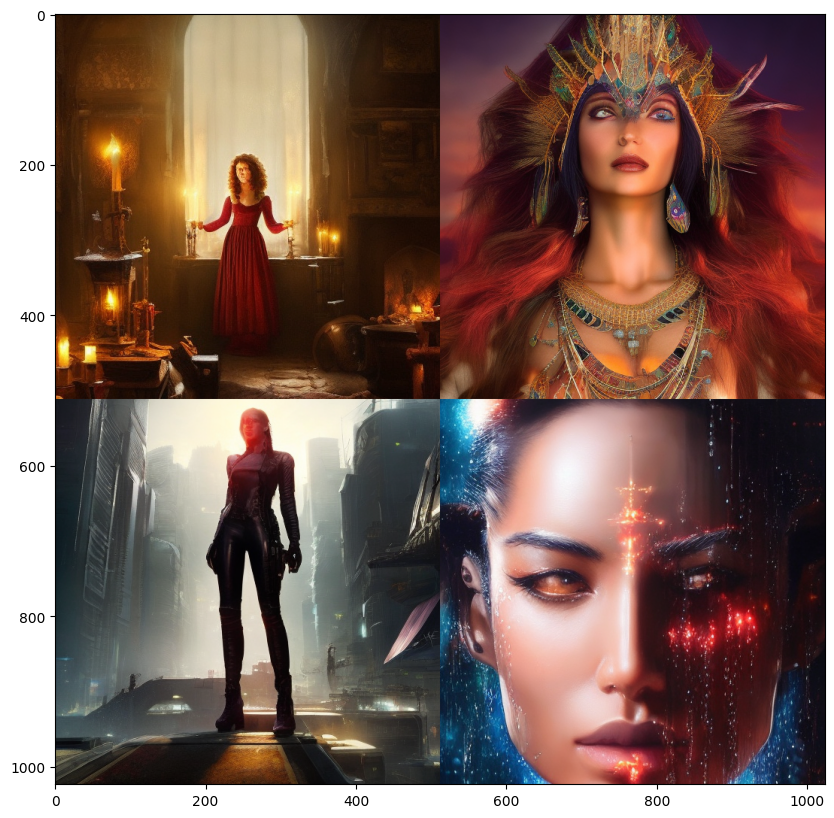

In [33]:
from matplotlib import pyplot as plt
f,ax = plt.subplots( figsize=(10, 10))
plt.imshow(I)

In [23]:
(
qnn.model.down_blocks[0].attentions[0].transformer_blocks[0].attn1.full_name,#act_quantizer_w # mm2
qnn.model.down_blocks[0].attentions[1].transformer_blocks[0].attn1.full_name,#act_quantizer_w # mm6
qnn.model.up_blocks[3].attentions[0].transformer_blocks[0].attn1.full_name, #act_quantizer_w #mm54
qnn.model.up_blocks[3].attentions[1].transformer_blocks[0].attn1.full_name, #act_quantizer_w #mm58
qnn.model.up_blocks[3].attentions[2].transformer_blocks[0].attn1.full_name,# act_quantizer_w #mm62
)

('down_blocks.0.attentions.0.transformer_blocks.0.attn1',
 'down_blocks.0.attentions.1.transformer_blocks.0.attn1',
 'up_blocks.3.attentions.0.transformer_blocks.0.attn1',
 'up_blocks.3.attentions.1.transformer_blocks.0.attn1',
 'up_blocks.3.attentions.2.transformer_blocks.0.attn1')

In [77]:
! ls -l {qdiff_opt_path / 'limvals'} 

12983.99s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


total 50
-rw-r--r-- 1 nadavg ht 17615 May  7 14:15 convs_limvals.csv
-rw-r--r-- 1 nadavg ht  7519 May  7 14:15 lnorm_limvals.csv
-rw-r--r-- 1 nadavg ht  3061 May  7 14:15 matmul1_limvals.csv
-rw-r--r-- 1 nadavg ht  2582 May  7 14:15 matmul2_limvals.csv


In [80]:
qdiff_matmul2_limvals

,layer_name,qdiff_min0,qdiff_max0,qdiff_min1,qdiff_max1
0,unet_sim/matmul2,0.0,0.736820,-3.609773,3.873903
1,unet_sim/matmul4,0.0,0.999920,-4.102359,3.704369
2,unet_sim/matmul6,0.0,0.740736,-3.477163,3.616249
3,unet_sim/matmul8,0.0,0.999684,-3.467868,3.440775
4,unet_sim/matmul10,0.0,0.752627,-5.499308,4.105648
5,unet_sim/matmul12,0.0,0.999944,-5.324006,2.954174
6,unet_sim/matmul14,0.0,0.880370,-2.807097,2.873933
7,unet_sim/matmul16,0.0,0.999935,-4.000933,4.361673
8,unet_sim/matmul18,0.0,0.912973,-2.752467,2.730963
9,unet_sim/matmul20,0.0,0.997668,-3.366632,3.237146


In [22]:
matmul1_limvals= uu.get_matmul1_limvals()

In [23]:
uu.limvals_to_pd(matmul1_limvals,num_inputs=2)

,layer_name,qdiff_min0,qdiff_max0,qdiff_min1,qdiff_max1
0,unet_sim/matmul1,-1.455453,1.466913,-2.781079,2.847295
1,unet_sim/matmul3,-0.990180,1.029788,-4.474947,3.977731
2,unet_sim/matmul5,-1.757833,1.663903,-3.281942,3.256302
3,unet_sim/matmul7,-0.664096,0.638554,-5.800432,4.995993
4,unet_sim/matmul9,-1.614871,1.504766,-2.149647,2.066968
5,unet_sim/matmul11,-1.395912,1.451748,-3.539004,3.797955
6,unet_sim/matmul13,-1.564845,1.552619,-1.768394,1.810499
7,unet_sim/matmul15,-1.120597,1.165421,-3.739113,3.709901
8,unet_sim/matmul17,-1.135620,1.199728,-1.239716,1.230031
9,unet_sim/matmul19,-1.676506,1.743566,-3.040242,3.112628


In [58]:
!ls -l {qdiff_opt_path / 'limvals' }

total 42
-rw-r--r-- 1 nadavg ht 17594 May  4 14:54 convs_limvals.csv
-rw-r--r-- 1 nadavg ht  7529 May  4 14:54 lnorm_limvals.csv
-rw-r--r-- 1 nadavg ht  1354 May  4 14:54 matmul2_limvals.csv


In [57]:
qdiff_matmul2_limvals

,layer_name,qdiff_min,qdiff_max
0,unet_sim/matmul2,0.000000,0.761703
1,unet_sim/matmul4,0.000000,0.999926
2,unet_sim/matmul6,0.000000,0.749133
3,unet_sim/matmul8,0.000000,0.999716
4,unet_sim/matmul10,0.000000,0.755953
5,unet_sim/matmul12,0.000000,0.999944
6,unet_sim/matmul14,0.000000,0.873755
7,unet_sim/matmul16,0.000000,0.999935
8,unet_sim/matmul18,0.000000,0.910148
9,unet_sim/matmul20,0.000000,0.997765


In [22]:
aq_params = qdiff_opt_path / 'aq_params.pth'
wq_params = qdiff_opt_path / 'wq_params.pth' 
opt_params = qdiff_opt_path / 'opt.pth'
qdiff_opt_model = qdiff_opt_path / 'ckpt.pth' #ver3

In [26]:
opt = torch.load(opt_params,weights_only=False)

In [28]:
opt.__dict__.keys()

dict_keys(['prompt', 'outdir', 'skip_grid', 'skip_save', 'ddim_steps', 'plms', 'laion400m', 'fixed_code', 'ddim_eta', 'n_iter', 'H', 'W', 'C', 'f', 'n_samples', 'n_rows', 'scale', 'from_file', 'config', 'ckpt', 'seed', 'precision', 'ptq', 'quant_act', 'quant_act_ops', 'split_to_16bits', 'gen_val_images', 'fp_model_path', 'accum_batches', 'weight_bit', 'symmetric_weight', 'act_bit', 'quant_mode', 'naive_weights_quant', 'rev_order', 'unite_kvq_act', 'unite_skip_ln', 'cali_st', 'cali_batch_size', 'cali_n', 'cali_iters', 'cali_iters_a', 'cali_lr', 'cali_p', 'cali_ckpt', 'cali_data_path', 'resume', 'resume_w', 'cond', 'no_grad_ckpt', 'split', 'running_stat', 'rs_sm_only', 'sm_abit', 'verbose', 'debug'])

In [32]:
fp_model_path = opt.fp_model_path
wq_params = {'n_bits': opt.weight_bit, 'channel_wise': True, 'scale_method': 'max',
             'symmetric': opt.symmetric_weight ,'debug':False}
aq_params = {'n_bits': 8, 'channel_wise': False, 'scale_method': 'max', 
                        'leaf_param': True, 'debug':False,'split_to_16bits':opt.split_to_16bits,
                        'act_quant_mode' :'qdiff'}
split = opt.split
sm_abit = opt.sm_abit
quant_act_ops = opt.quant_act_ops
unite_kvq_act = opt.unite_kvq_act
unite_skip_ln = opt.unite_skip_ln
             

In [ ]:
fp_model_path =  '/genai/users/ellaf/stable_diffusion/unet/shared_unet_demo/quantize_params_10_03/unet_sim_eq.har'
#qdiff_opt_model = '/workspace/sd/qdiff_hf15/output_quantization/2025-04-15-18-06-48/ckpt.pth' #ver2
qdiff_opt_model = '/workspace/sd/qdiff_hf15/output_quantization/2025-04-29-11-17-50/ckpt.pth' #ver3

wq_params = {'n_bits': 8, 'channel_wise': True, 'scale_method': 'max',
                        'symmetric':True,'debug':False}

aq_params = {'n_bits': 8, 'channel_wise': False, 'scale_method': 'max', 
                        'leaf_param': True, 'debug':False,'split_to_16bits':False,'act_quant_mode' :'qdiff'}
split = False
sm_abit = 8
quant_act_ops = True
unite_kvq_act = True
unite_skip_ln = True

In [11]:
cali_data_path ='/genai/users/nadavg/sd/qdiff_hf15_verb/gen_calib/calib_dict_steps20.pt' 
sample_data = torch.load(cali_data_path)
dummy_args = namedtuple('Args',['cali_n','cali_st','custom_steps','cond'])
opt = dummy_args(1,20,None,True)
cali_data = get_train_samples(opt, sample_data,20)
cali_xs, cali_ts, cali_cs = cali_data

/tmp/ipykernel_3112981/2612644150.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sample_data = torch.load(cali_data_path)


In [12]:
cali_xs.shape,cali_ts.shape,cali_cs.shape   

(torch.Size([40, 4, 64, 64]), torch.Size([40]), torch.Size([40, 77, 768]))

In [13]:
#input_bach = [torch.randn((1, 4, 64, 64)),torch.randn(1),torch.randn((1,77,768))]
#input_bach[0].shape,input_bach[1].shape,input_bach[2].shape

In [14]:
#pipe.to('cuda')

In [15]:
#ace_unet_path =  '/genai/users/ellaf/stable_diffusion/unet/shared_unet_demo/unet_sim_fp.har'
#ace_unet_path = '/genai/users/ellaf/stable_diffusion/unet/shared_unet_demo/quant_params/unet_eq_pre_ln.har'
ace_unet_path = '/genai/users/ellaf/stable_diffusion/unet/shared_unet_demo/quantize_params_10_03/unet_sim_eq.har'

#get_har_files(ace_unet_path)

In [16]:
input_bach = [cali_xs[0:1],cali_ts[0:1],cali_cs[0:1]]

In [17]:
if False:
    fp_model_path =  '/genai/users/ellaf/stable_diffusion/unet/shared_unet_demo/quantize_params_10_03/unet_sim_eq.har'
    wq_params = {'n_bits': 8, 'channel_wise': True, 'scale_method': 'max',
                        'symmetric':True,'debug':False}

    aq_params = {'n_bits': 8, 'channel_wise': False, 'scale_method': 'max', 
                        'leaf_param': True, 'debug':False,'split_to_16bits':False,'act_quant_mode' :'qdiff'}
    split = True
    sm_abit = 16
    quant_act_ops = True
    unite_kvq_act = True
    unite_skip_ln = True

In [ ]:
if 0:#False:
    fp_model_path =  '/genai/users/ellaf/stable_diffusion/unet/shared_unet_demo/quantize_params_10_03/unet_sim_eq.har'
    #qdiff_opt_model = '/workspace/sd/qdiff_hf15/output_quantization/2025-04-15-18-06-48/ckpt.pth' #ver2
    qdiff_opt_model = '/workspace/sd/qdiff_hf15/output_quantization//2025-04-22-17-24-29/ckpt.pth' #ver3

    wq_params = {'n_bits': 8, 'channel_wise': True, 'scale_method': 'max',
                        'symmetric':True,'debug':False}

    aq_params = {'n_bits': 8, 'channel_wise': False, 'scale_method': 'max', 
                        'leaf_param': True, 'debug':False,'split_to_16bits':False,'act_quant_mode' :'qdiff'}
    split = False
    sm_abit = 16
    quant_act_ops = True
    unite_kvq_act = True
    unite_skip_ln = True

In [19]:
if 1:#False:
    fp_model_path =  '/genai/users/ellaf/stable_diffusion/unet/shared_unet_demo/quantize_params_10_03/unet_sim_eq.har'
    #qdiff_opt_model = '/workspace/sd/qdiff_hf15/output_quantization/2025-04-15-18-06-48/ckpt.pth' #ver2
    qdiff_opt_model = '/workspace/sd/qdiff_hf15/output_quantization/2025-04-29-11-17-50/ckpt.pth' #ver3

    wq_params = {'n_bits': 8, 'channel_wise': True, 'scale_method': 'max',
                        'symmetric':True,'debug':False}

    aq_params = {'n_bits': 8, 'channel_wise': False, 'scale_method': 'max', 
                        'leaf_param': True, 'debug':False,'split_to_16bits':False,'act_quant_mode' :'qdiff'}
    split = False
    sm_abit = 8
    quant_act_ops = True
    unite_kvq_act = True
    unite_skip_ln = True

In [20]:
qnn,pipe,uu = init_qnn_from_fp_model(
    fp_model_path, weight_quant_params=wq_params, act_quant_params=aq_params,scheduler = 'euler',
    out_uu=True,
    act_quant_mode="qdiff", sm_abit=sm_abit, quant_act_ops = quant_act_ops, split=split,
    unite_kvq_act = unite_kvq_act,unite_skip_ln= unite_skip_ln)

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/home/nadavg/phase2-sdk/sdk_virtualenv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, plea

SNR of acceleras fp model : 122.30699100303332 [db]


In [21]:
qnn.load_from_state_dict(qdiff_opt_model)

/home/nadavg/q-diffusion/qdiff/quant_model.py:193: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  m.delta = nn.Parameter(torch.tensor(m.delta,dtype=torch.float32))
/home/nadavg/q-diffusion/qdiff/quant_model.py:197: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  m.zero_point = nn.Parameter(torch.tensor(m.zero_point,dtype=torch.float32))
/home/nadavg/q-diffusion/qdiff/quant_model.py:200: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md

In [36]:
qdiff_matmul2_limvals = uu.get_matmul2_limvals()

In [41]:
qdiff_matmul2_limvals

{'unet_sim/matmul2': array([0.        , 0.08572967], dtype=float32),
 'unet_sim/matmul4': array([0.       , 0.5949397], dtype=float32),
 'unet_sim/matmul6': array([0.       , 0.1472323], dtype=float32),
 'unet_sim/matmul8': array([0.       , 0.8753008], dtype=float32),
 'unet_sim/matmul10': array([0.       , 0.2770182], dtype=float32),
 'unet_sim/matmul12': array([0.        , 0.93900996], dtype=float32),
 'unet_sim/matmul14': array([0.        , 0.38183326], dtype=float32),
 'unet_sim/matmul16': array([0.       , 0.8285123], dtype=float32),
 'unet_sim/matmul18': array([0.       , 0.7149924], dtype=float32),
 'unet_sim/matmul20': array([0.       , 0.5304482], dtype=float32),
 'unet_sim/matmul22': array([0.       , 0.5513584], dtype=float32),
 'unet_sim/matmul24': array([0.       , 0.5104668], dtype=float32),
 'unet_sim/matmul26': array([0.        , 0.76032656], dtype=float32),
 'unet_sim/matmul28': array([0.        , 0.63498896], dtype=float32),
 'unet_sim/matmul30': array([0.       , 0.

In [42]:
qdiff_convs_limvals = uu.get_convs_limvals()


In [43]:
qdiff_lnorm_limvals = uu.get_lnorm_limvals()

In [46]:
qdiff_lnorm_limvals

{'unet_sim/layer_normalization1': array([-3.888333 ,  4.2389207], dtype=float32),
 'unet_sim/layer_normalization2': array([-12.814038 ,   6.7523074], dtype=float32),
 'unet_sim/layer_normalization3': array([-5.139365 ,  4.4969444], dtype=float32),
 'unet_sim/layer_normalization4': array([-1.3069255,  2.3960302], dtype=float32),
 'unet_sim/layer_normalization5': array([-1.5474586,  2.0398319], dtype=float32),
 'unet_sim/layer_normalization6': array([-1.9620545,  2.3885882], dtype=float32),
 'unet_sim/layer_normalization7': array([-5.566921,  4.089983], dtype=float32),
 'unet_sim/layer_normalization8': array([-3.7661417,  2.510761 ], dtype=float32),
 'unet_sim/layer_normalization9': array([-5.765349 ,  4.1015234], dtype=float32),
 'unet_sim/layer_normalization10': array([-3.147056,  2.886773], dtype=float32),
 'unet_sim/layer_normalization11': array([-4.2311  ,  2.685121], dtype=float32),
 'unet_sim/layer_normalization12': array([-5.260136 ,  2.4932437], dtype=float32),
 'unet_sim/layer_

In [51]:
#q_har_path = '/genai/users/nadavg/sd/acceleras_verd/qdiff_verd/unet_sim_all_q.har'
q_har_path = '/genai/users/nadavg/sd/acceleras_verd/qdiff_verd_ver2_qdiff/unet_sim_all_q.har'
#q_har_path = '/genai/users/nadavg/sd/acceleras_verd/qdiff_verd_ver2_qdiff_conv_lnorm/unet_sim_all_q.har'


#get_har_files(q_har_path)
params = get_params_from_har(q_har_path,params_name='unet_sim.ho.npz')

all_names=['unet_sim.hn', 'unet_sim.q.npz', 'unet_sim.alls', 'unet_sim.native.hn', 'unet_sim.fp.hn', 'unet_sim.npz', 'unet_sim.fpo.npz', 'unet_sim.ho.npz', 'unet_sim.stats.npz', 'unet_sim.original_model_meta.json', 'unet_sim.metadata.json']
loading  params_name='unet_sim.ho.npz' ...


In [68]:
acc_matmul2_limvals = uu.get_matmul2_limvals_from_szp_acceleras(params)

In [40]:
acc_matmul2_limvals

NameError: name 'acc_matmul2_limvals' is not defined

In [32]:
alls = get_params_from_har(q_har_path,params_name='unet_sim.alls')

all_names=['unet_sim.hn', 'unet_sim.q.npz', 'unet_sim.alls', 'unet_sim.native.hn', 'unet_sim.fp.hn', 'unet_sim.npz', 'unet_sim.fpo.npz', 'unet_sim.ho.npz', 'unet_sim.stats.npz', 'unet_sim.original_model_meta.json', 'unet_sim.metadata.json']
loading  params_name='unet_sim.alls' ...


In [34]:
#print(alls)

In [31]:
acc_convs_limvals = uu.get_convs_limvals_from_szp_acceleras(params)

In [32]:
acc_lnorm_limvals = uu.get_layer_norm_limvals_from_szp_acceleras(params)

In [33]:
acc_lnorm_limvals

{'unet_sim/layer_normalization1': (-6.952060490293661, 8.98345305188559),
 'unet_sim/layer_normalization2': (-33.79085261200089, 19.97097635315731),
 'unet_sim/layer_normalization3': (-12.195654388982803, 9.051421715004835),
 'unet_sim/layer_normalization4': (-2.743887958175037, 4.87616261607036),
 'unet_sim/layer_normalization5': (-2.5889115746686002, 3.288651341368677),
 'unet_sim/layer_normalization6': (-2.768829646447557, 3.659728493221337),
 'unet_sim/layer_normalization7': (-8.499575911147986, 7.583210014854558),
 'unet_sim/layer_normalization8': (-6.884336790826637, 5.0214564020279795),
 'unet_sim/layer_normalization9': (-10.00362676475197, 8.279998748446815),
 'unet_sim/layer_normalization10': (-4.773848725249991, 4.358840507600689),
 'unet_sim/layer_normalization11': (-5.476778418640606, 2.826446420280263),
 'unet_sim/layer_normalization12': (-6.4004952408140525, 3.532959386939183),
 'unet_sim/layer_normalization13': (-14.027258517686278, 14.638774901861325),
 'unet_sim/layer_

In [70]:
import pandas as pd
#qdiff_limvals = qdiff_lnorm_limvals
#acc_limvals = acc_lnorm_limvals
qdiff_limvals = qdiff_matmul2_limvals
acc_limvals = acc_matmul2_limvals

lmvals=pd.DataFrame(columns=['layer_name','qdiff_range','acc_range',
                             'qdiff_min','qdiff_max','acc_min','acc_max'])
for k in qdiff_limvals.keys():
    if qdiff_limvals[k][0] is None:
        continue
    qdiff_min = qdiff_limvals[k][0]
    qdiff_max = qdiff_limvals[k][1]
    acc_min = acc_limvals[k][0]
    acc_max = acc_limvals[k][1]
    layer_name = k
    lmvals = lmvals.append({'layer_name':layer_name,
                            'qdiff_range':qdiff_max-qdiff_min,
                            'acc_range':acc_max-acc_min,
                            'qdiff_min':qdiff_min,'qdiff_max':qdiff_max,
                            'acc_min':acc_min,'acc_max':acc_max},ignore_index=True)
    

In [73]:
#lmvals.to_csv('/genai/users/nadavg/sd/acceleras_verd/qdiff_verd/layer_norm_ranges_all_ver3.csv')
lmvals.to_csv('/genai/users/nadavg/sd/acceleras_verd/qdiff_verd/matmul2_ranges_all_ver3.csv')

In [72]:
lmvals[:]

,layer_name,qdiff_range,acc_range,qdiff_min,qdiff_max,acc_min,acc_max
0,unet_sim/matmul2,0.085730,0.989427,0.0,0.085730,0.0,0.989427
1,unet_sim/matmul4,0.594940,0.999999,0.0,0.594940,0.0,0.999999
2,unet_sim/matmul6,0.147232,0.973150,0.0,0.147232,0.0,0.973150
3,unet_sim/matmul8,0.875301,0.999998,0.0,0.875301,0.0,0.999998
4,unet_sim/matmul10,0.277018,0.990308,0.0,0.277018,0.0,0.990308
5,unet_sim/matmul12,0.939010,0.999992,0.0,0.939010,0.0,0.999992
6,unet_sim/matmul14,0.381833,0.996907,0.0,0.381833,0.0,0.996907
7,unet_sim/matmul16,0.828512,1.000000,0.0,0.828512,0.0,1.000000
8,unet_sim/matmul18,0.714992,0.998047,0.0,0.714992,0.0,0.998047
9,unet_sim/matmul20,0.530448,0.999347,0.0,0.530448,0.0,0.999347


In [32]:
q_har_path = '/genai/users/nadavg/sd/acceleras_verd/qdiff_verd/unet_sim_0_q.har'
params0 = get_params_from_har(q_har_path,params_name='unet_sim.ho.npz')
q_har_path = '/genai/users/nadavg/sd/acceleras_verd/qdiff_verd/unet_sim_1_q.har'
params1 = get_params_from_har(q_har_path,params_name='unet_sim.ho.npz')
q_har_path = '/genai/users/nadavg/sd/acceleras_verd/qdiff_verd/unet_sim_2_q.har'
params2 = get_params_from_har(q_har_path,params_name='unet_sim.ho.npz')
q_har_path = '/genai/users/nadavg/sd/acceleras_verd/qdiff_verd/unet_sim_3_q.har'
params3 = get_params_from_har(q_har_path,params_name='unet_sim.ho.npz')

all_names=['unet_sim.hn', 'unet_sim.q.npz', 'unet_sim.alls', 'unet_sim.native.hn', 'unet_sim.fp.hn', 'unet_sim.npz', 'unet_sim.fpo.npz', 'unet_sim.ho.npz', 'unet_sim.stats.npz', 'unet_sim.original_model_meta.json', 'unet_sim.metadata.json']
loading  params_name='unet_sim.ho.npz' ...
all_names=['unet_sim.hn', 'unet_sim.q.npz', 'unet_sim.alls', 'unet_sim.native.hn', 'unet_sim.fp.hn', 'unet_sim.npz', 'unet_sim.fpo.npz', 'unet_sim.ho.npz', 'unet_sim.stats.npz', 'unet_sim.original_model_meta.json', 'unet_sim.metadata.json']
loading  params_name='unet_sim.ho.npz' ...
all_names=['unet_sim.hn', 'unet_sim.q.npz', 'unet_sim.alls', 'unet_sim.native.hn', 'unet_sim.fp.hn', 'unet_sim.npz', 'unet_sim.fpo.npz', 'unet_sim.ho.npz', 'unet_sim.stats.npz', 'unet_sim.original_model_meta.json', 'unet_sim.metadata.json']
loading  params_name='unet_sim.ho.npz' ...
all_names=['unet_sim.hn', 'unet_sim.q.npz', 'unet_sim.alls', 'unet_sim.native.hn', 'unet_sim.fp.hn', 'unet_sim.npz', 'unet_sim.fpo.npz', 'unet_sim.h

In [23]:
uu.debug = False

In [26]:
qdiff_limvals = uu.get_convs_limvals()

In [29]:
import pandas as pd
import numpy as np


In [30]:
lmvals=pd.DataFrame(columns=['layer_name','qdiff_min','qdiff_max'])
for k in qdiff_limvals.keys():

    qdiff_min = qdiff_limvals[k][0]
    qdiff_max = qdiff_limvals[k][1]
    layer_name = k
    lmvals = lmvals.append({'layer_name':layer_name,
                            'qdiff_min':qdiff_min,'qdiff_max':qdiff_max,},
                            ignore_index=True)
    

In [39]:
#qdiff_lnorm_limvals

In [40]:
lmvals=pd.DataFrame(columns=['layer_name','qdiff_min','qdiff_max'])
for k in qdiff_lnorm_limvals.keys():

    qdiff_min = qdiff_lnorm_limvals[k][0]
    qdiff_max = qdiff_lnorm_limvals[k][1]
    layer_name = k
    if qdiff_min is None:
        continue
    lmvals = lmvals.append({'layer_name':layer_name,
                            'qdiff_min':qdiff_min,'qdiff_max':qdiff_max,},
                            ignore_index=True)
    

In [41]:
lmvals.to_csv('/genai/users/nadavg/sd/acceleras_verd/qdiff_verd/lmvals_lnorm_qdiff_ver3.csv', index=False)

In [55]:
pd.read_csv

<function pandas.io.parsers.read_csv(filepath_or_buffer: Union[str, pathlib.Path, IO[~AnyStr]], sep=',', delimiter=None, header='infer', names=None, index_col=None, usecols=None, squeeze=False, prefix=None, mangle_dupe_cols=True, dtype=None, engine=None, converters=None, true_values=None, false_values=None, skipinitialspace=False, skiprows=None, skipfooter=0, nrows=None, na_values=None, keep_default_na=True, na_filter=True, verbose=False, skip_blank_lines=True, parse_dates=False, infer_datetime_format=False, keep_date_col=False, date_parser=None, dayfirst=False, cache_dates=True, iterator=False, chunksize=None, compression='infer', thousands=None, decimal: str = '.', lineterminator=None, quotechar='"', quoting=0, doublequote=True, escapechar=None, comment=None, encoding=None, dialect=None, error_bad_lines=True, warn_bad_lines=True, delim_whitespace=False, low_memory=True, memory_map=False, float_precision=None)>

In [42]:
lmvals=pd.read_csv('/genai/users/nadavg/sd/acceleras_verd/qdiff_verd/lmvals_lnorm_qdiff_ver3.csv')

In [44]:
lmvals[:10]

,layer_name,qdiff_min,qdiff_max
0,unet_sim/layer_normalization1,-3.888333,4.238921
1,unet_sim/layer_normalization2,-12.814038,6.752307
2,unet_sim/layer_normalization3,-5.139365,4.496944
3,unet_sim/layer_normalization4,-1.331240,2.440607
4,unet_sim/layer_normalization5,-1.706420,2.249372
5,unet_sim/layer_normalization6,-2.166385,2.595927
6,unet_sim/layer_normalization7,-5.562073,4.086421
7,unet_sim/layer_normalization8,-3.656844,2.818817
8,unet_sim/layer_normalization9,-5.765359,4.101531
9,unet_sim/layer_normalization10,-3.199055,3.028113


In [43]:
qdiff_limvals['unet_sim/conv1']

KeyError: 'unet_sim/conv1'

In [25]:
acc_limvals = uu.get_convs_limvals_acceleras(params)

In [34]:
acc_limvals0 = uu.get_convs_limvals_acceleras(params0)
acc_limvals1 = uu.get_convs_limvals_acceleras(params1)
acc_limvals2 = uu.get_convs_limvals_acceleras(params2)
acc_limvals3 = uu.get_convs_limvals_acceleras(params3)

In [35]:
len(qdiff_limvals), len(acc_limvals),len(acc_limvals0),len(acc_limvals1),len(acc_limvals2),len(acc_limvals3)

(298, 298, 298, 298, 298, 298)

In [30]:
lmvals=pd.DataFrame(columns=['layer_name','qdiff_range','acc_range'])
for k in qdiff_limvals.keys():

    qdiff_min = qdiff_limvals[k][0]
    qdiff_max = qdiff_limvals[k][1]
    acc_min = acc_limvals[k][0]
    acc_max = acc_limvals[k][1]
    layer_name = k
    lmvals = lmvals.append({'layer_name':layer_name,'qdiff_range':qdiff_max-qdiff_min,
                            'acc_range':acc_max-acc_min},ignore_index=True)
    

In [36]:
lmvals=pd.DataFrame(columns=['layer_name','qdiff_range','all_range','0_range','1_range','2_range','3_range'])
for k in qdiff_limvals.keys():

    qdiff_min = qdiff_limvals[k][0]
    qdiff_max = qdiff_limvals[k][1]
    acc_min = acc_limvals[k][0]
    acc_max = acc_limvals[k][1]
    acc_min0 = acc_limvals0[k][0]
    acc_max0 = acc_limvals0[k][1]
    acc_min1 = acc_limvals1[k][0]
    acc_max1 = acc_limvals1[k][1]
    acc_min2 = acc_limvals2[k][0]
    acc_max2 = acc_limvals2[k][1]
    acc_min3 = acc_limvals3[k][0]
    acc_max3 = acc_limvals3[k][1]
    layer_name = k
    lmvals = lmvals.append({'layer_name':layer_name,'qdiff_range':qdiff_max-qdiff_min,
                            'all_range':acc_max-acc_min,
                            '0_range':acc_max0-acc_min0,
                            '1_range':acc_max1-acc_min1,
                            '2_range':acc_max2-acc_min2,
                            '3_range':acc_max3-acc_min3,
                            },ignore_index=True)
    

In [39]:
# savbe the dataframe to a csv file
lmvals.to_csv('/genai/users/nadavg/sd/acceleras_verd/qdiff_verd/lmvals_all.csv', index=False)
lmvals1 = pd.read_csv('/genai/users/nadavg/sd/acceleras_verd/qdiff_verd/lmvals_all.csv')

In [51]:
lmvals1[90:110]#.tail()

,layer_name,qdiff_range,all_range,0_range,1_range,2_range,3_range
90,unet_sim/conv_feature_splitter5_3,24.359970,29.698669,29.417076,29.932907,29.353649,29.506138
91,unet_sim/conv60,6.000717,6.691712,4.755947,6.346185,7.194002,8.346838
92,unet_sim/conv61,21.887058,28.021461,24.272621,26.519684,28.021660,27.447433
93,unet_sim/conv62,5.926690,8.113263,8.178084,7.937040,8.185692,7.981343
94,unet_sim/conv_feature_splitter6_1,21.764721,30.126436,26.300529,28.624891,30.181889,30.052557
95,unet_sim/conv_feature_splitter6_2,21.764721,30.126436,26.300529,28.624891,30.181889,30.052557
96,unet_sim/conv64,7.822667,23.279041,21.738506,25.241129,23.615583,24.969124
97,unet_sim/conv65,10.087134,11.646399,9.524416,9.841843,10.790382,11.776466
98,unet_sim/conv66,4.008645,5.733428,5.289551,6.520611,6.468277,5.351158
99,unet_sim/conv67,5.235981,12.572488,6.166182,12.032501,12.572307,10.987754


In [34]:
qdiff_limvals

{'unet_sim/conv1': array([-7.1664853,  6.2706747], dtype=float32),
 'unet_sim/fc1': array([-0.996072 ,  1.0039151], dtype=float32),
 'unet_sim/fc2': array([-0.28111622,  5.6926036 ], dtype=float32),
 'unet_sim/fc10': array([-0.4309921,  4.802483 ], dtype=float32),
 'unet_sim/fc11': array([-0.41429773,  4.6164603 ], dtype=float32),
 'unet_sim/fc12': array([-0.41326332,  4.604934  ], dtype=float32),
 'unet_sim/fc13': array([-0.40636376,  4.5280533 ], dtype=float32),
 'unet_sim/fc14': array([-0.39199662,  4.3679624 ], dtype=float32),
 'unet_sim/fc15': array([-0.44428468,  4.9506006 ], dtype=float32),
 'unet_sim/fc16': array([-0.39698502,  4.4235473 ], dtype=float32),
 'unet_sim/fc17': array([-0.40871605,  4.5542645 ], dtype=float32),
 'unet_sim/fc18': array([-0.40894634,  4.5568304 ], dtype=float32),
 'unet_sim/fc19': array([-0.41044727,  4.5735555 ], dtype=float32),
 'unet_sim/fc20': array([-0.40841025,  4.550857  ], dtype=float32),
 'unet_sim/fc21': array([-0.4044553,  4.506788 ], dtype

In [52]:
uu.hn['layers']['unet_sim/layer_normalization1']['original_names']

['/down_blocks.0/resnets.0/norm1/Reshape',
 '/down_blocks.0/resnets.0/norm1/InstanceNormalization',
 '/down_blocks.0/resnets.0/norm1/Reshape_1']

In [150]:
#lname = 'unet_sim/conv48'
lname = 'unet_sim/fc2'
#lname = 'unet_sim/conv_feature_splitter3_2'
m,act= uu.get_conv_act(lname)


lname=unet_sim/fc2 type=dense layer_norm_input=False,ff_input=False,kqv=False


In [165]:
act.n_levels

256

In [151]:
m.full_name,act.full_name
#act.full_name

('time_embedding.linear_2', 'time_embedding.linear_2.act_quantizer')

In [143]:
uu.unet.down_blocks[0].resnets[0].emb_layers[1]#.proj)

QuantModule(
  in_features=1280, out_features=320, bias=True
  (weight_quantizer): UniformAffineQuantizer(bit=8, scale_method=max, symmetric=True, channel_wise=True, leaf_param=False)
  (act_quantizer): UniformAffineQuantizer(bit=8, scale_method=max, symmetric=False, channel_wise=False, leaf_param=True)
  (activation_function): StraightThrough()
)

In [106]:
uu.unet.down_blocks[0].attentions[0].transformer_blocks[0].ff.net[0].forward

<bound method GEGLU.forward of GEGLU(
  (proj): QuantModule(
    in_features=320, out_features=2560, bias=True
    (weight_quantizer): UniformAffineQuantizer(bit=8, scale_method=max, symmetric=True, channel_wise=True, leaf_param=False)
    (act_quantizer): UniformAffineQuantizer(bit=8, scale_method=max, symmetric=False, channel_wise=False, leaf_param=True)
    (activation_function): StraightThrough()
  )
)>

In [38]:
qnn.model.down_blocks[1].resnets[0]

QuantResBlockHF15(
  (activation_function): StraightThrough()
  (dropout): Dropout(p=0.0, inplace=False)
  (in_layers): Sequential(
    (0): QuantOp(
      (fwd_func): GroupNorm32(32, 320, eps=1e-05, affine=True)
      (act_quantizer): None
      (activation_function): StraightThrough()
    )
    (1): QuantOp(
      (fwd_func): SiLU()
      (act_quantizer): UniformAffineQuantizer(bit=8, scale_method=max, symmetric=False, channel_wise=False, leaf_param=True)
      (activation_function): StraightThrough()
    )
    (2): QuantModule(
      320, 640, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)
      (weight_quantizer): UniformAffineQuantizer(bit=8, scale_method=max, symmetric=True, channel_wise=True, leaf_param=False)
      (act_quantizer): UniformAffineQuantizer(bit=8, scale_method=max, symmetric=False, channel_wise=False, leaf_param=True)
      (activation_function): StraightThrough()
    )
  )
  (emb_layers): Sequential(
    (0): QuantOp(
      (fwd_func): SiLU()
      (act_quanti

In [40]:
m.full_name.replace('skip_connection','act_op_skip_ln')+'.act_quantizer'

'down_blocks.1.resnets.0.act_op_skip_ln.act_quantizer'

In [21]:
delta = qnn.model.conv_in.act_quantizer.delta 
zp = qnn.model.conv_in.act_quantizer.zero_point
delta,zp

(Parameter containing:
 tensor(0.0527, requires_grad=True),
 Parameter containing:
 tensor(136., requires_grad=True))

In [23]:
act_q = qnn.model.down_blocks[0].resnets[0].in_layers[2].act_quantizer
act_q.inited

True

In [21]:
act_q = qnn.model.down_blocks[0].attentions[0].transformer_blocks[0].attn1.act_quantizer_to_kvq
act_q

UniformAffineQuantizer(bit=8, scale_method=max, symmetric=False, channel_wise=False, leaf_param=True)

In [33]:
delta = act_q.delta 
zp = act_q.zero_point
delta,zp

(Parameter containing:
 tensor(0.0606, requires_grad=True),
 Parameter containing:
 tensor(126., requires_grad=True))

In [34]:
(0-zp)*delta,(2**8-zp)*delta

(tensor(-7.6373, grad_fn=<MulBackward0>),
 tensor(7.8797, grad_fn=<MulBackward0>))

In [ ]:
q_har_path = '/genai/users/nadavg/sd/acceleras_verd/qdiff_verd/unet_sim_all_q.har'
get_har_files(q_har_path)
params = get_params_from_har(q_har_path,params_name='unet_sim.ho.npz')

['unet_sim.hn',
 'unet_sim.q.npz',
 'unet_sim.alls',
 'unet_sim.native.hn',
 'unet_sim.fp.hn',
 'unet_sim.npz',
 'unet_sim.fpo.npz',
 'unet_sim.ho.npz',
 'unet_sim.stats.npz',
 'unet_sim.original_model_meta.json',
 'unet_sim.metadata.json']

In [26]:
#stats = get_params_from_har(q_har_path,params_name='unet_sim.stats.npz')

In [27]:
params = get_params_from_har(q_har_path,params_name='unet_sim.ho.npz')

all_names=['unet_sim.hn', 'unet_sim.q.npz', 'unet_sim.alls', 'unet_sim.native.hn', 'unet_sim.fp.hn', 'unet_sim.npz', 'unet_sim.fpo.npz', 'unet_sim.ho.npz', 'unet_sim.stats.npz', 'unet_sim.original_model_meta.json', 'unet_sim.metadata.json']
loading  params_name='unet_sim.ho.npz' ...


In [68]:
kp = [k for k in params.keys() if 'conv34/' in k]
kp

['unet_sim/conv34/stats/input_0/energy:0',
 'unet_sim/conv34/stats/input_0/mean:0',
 'unet_sim/conv34/stats/input_0/min:0',
 'unet_sim/conv34/stats/input_0/non_zero_percent:0',
 'unet_sim/conv34/stats/input_0/max:0',
 'unet_sim/conv34/stats/input_0/stats_limvals:0',
 'unet_sim/conv34/stats/preact/energy:0',
 'unet_sim/conv34/stats/preact/mean:0',
 'unet_sim/conv34/stats/preact/min:0',
 'unet_sim/conv34/stats/preact/non_zero_percent:0',
 'unet_sim/conv34/stats/preact/max:0',
 'unet_sim/conv34/stats/preact/stats_limvals:0',
 'unet_sim/conv34/stats/output_0/energy:0',
 'unet_sim/conv34/stats/output_0/mean:0',
 'unet_sim/conv34/stats/output_0/min:0',
 'unet_sim/conv34/stats/output_0/non_zero_percent:0',
 'unet_sim/conv34/stats/output_0/max:0',
 'unet_sim/conv34/stats/output_0/stats_limvals:0',
 'unet_sim/conv34/conv_op/mac_shift:0',
 'unet_sim/conv34/conv_op/shift_delta:0',
 'unet_sim/conv34/conv_op/kernel_scale:0',
 'unet_sim/conv34/conv_op/kernel_zero_point:0',
 'unet_sim/conv34/conv_op/

In [28]:
params['unet_sim/conv_feature_splitter1_3/stats/input_0/stats_limvals:0']

array([-9.356088,  9.529353], dtype=float32)

In [59]:
params['unet_sim/conv1/bias:0'],params['unet_sim/conv1/kernel:0']

(array([-0.08803573, -0.09711165,  0.09488692,  0.023821  ,  0.02168794,
        -0.04530066, -0.06198689,  0.05613245, -0.0148176 ,  0.02999938,
        -0.06980634, -0.02370729,  0.09361337,  0.08353423, -0.06225395,
        -0.08529324, -0.09720365,  0.04786959,  0.03226589,  0.0749637 ,
        -0.05567331,  0.04583589, -0.0496354 ,  0.04854185,  0.05000393,
        -0.00708514,  0.05893331, -0.05700348, -0.05409846,  0.03638504,
        -0.05645244,  0.0396337 ,  0.07801004, -0.02127886,  0.00313789,
         0.08753418, -0.08270735,  0.06485725,  0.03786063,  0.04398048,
         0.00127158,  0.03614601, -0.06271268, -0.09760955,  0.04874119,
        -0.01874899,  0.0113463 ,  0.04213689, -0.10549644, -0.08005385,
        -0.10157417, -0.13140552,  0.06077195,  0.03024662, -0.09054364,
         0.11797511,  0.02158069,  0.11478765,  0.02730303, -0.12702507,
         0.09665617, -0.04124267, -0.06146606, -0.07343603,  0.04003976,
        -0.07952477,  0.08095916, -0.02165104, -0.0